# Simple ML Models

Baseline classification pipelines using cleaned feature matrix `../data/X_features.parquet` and target labels `../data/y_targets.parquet`. This notebook trains a multi-output logistic regression model and reports cross-validated and held-out test performance.

Targets are devided in bleeding or ischemic problems.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
PROJECT_DIR = os.path.dirname(os.getcwd())
sys.path.append(PROJECT_DIR)

# Uniform plot style for all project charts
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

## Load Dataset

Load the cleaned feature matrix `X` from `../data/X_features.parquet` and the 9 binary clinical outcome targets `y_df` from `../data/y_targets.parquet`, produced by the data cleaning pipeline.

In [3]:
X = pd.read_parquet(os.path.join(PROJECT_DIR, '../data/X_features.parquet'))
y_df = pd.read_parquet(os.path.join(PROJECT_DIR, '../data/y_targets.parquet'))

target_features = y_df

## Explore Combined Target Groups

As a quick sanity check, group the 9 individual endpoints into two broad binary outcomes — *any bleeding event* (the 5 BARC-based bleeding targets) vs. *any ischemic event* (CV death, MI, stroke, revascularization) — and look at how often each combination occurs. This is purely exploratory and does not feed into the models below.

In [4]:
bleeding_targets = ['cec_barc3_335d', 'cec_barc35_335d', 'cec_barc2_335d', 'cec_barc235_335d', 'cec_bleed_335d']
ischemic_targets = [col for col in target_features.columns if col not in bleeding_targets]

y_bleeding = y_df[bleeding_targets].sum(axis=1).clip(0, 1)  # 1 if any bleeding endpoint occurred
y_ischemic = y_df[ischemic_targets].sum(axis=1).clip(0, 1)  # 1 if any ischemic endpoint occurred

y_generally = y_df.sum(axis=1).clip(0, 1)  # 1 if any endpoint occurred (bleeding or ischemic)

y_grouped = pd.concat([y_bleeding, y_ischemic, y_generally], keys=['bleeding', 'ischemic', 'generally'], axis=1)
y_grouped.value_counts()

bleeding  ischemic  generally
0         0         0            3840
1         0         1             432
0         1         1             233
1         1         1              74
Name: count, dtype: int64

## Pipeline Evaluation Utilities

`evaluate_pipeline` reports cross-validated F1 score statistics (at the default 0.5 threshold) for each target of a single- or multi-output classification pipeline. `predict_with_threshold` generates predictions from a custom per-target probability threshold instead of 0.5, which matters for classifiers like RandomForest whose averaged probabilities rarely exceed 0.5 for rare events.

In [5]:
from pipeline_utils import evaluate_pipeline, predict_with_threshold, save_pipeline

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_grouped, test_size=0.2, random_state=42
)

## Multi-output Logistic Regression Pipeline

Split the data, build a scaling + logistic regression pipeline wrapped for multi-output classification, cross-validate it on the training set, fit it, and report per-target classification metrics on the held-out test set.

Cross-validation on the training set



--- bleeding ---
F1 scores: [0.49473271 0.47911162 0.4652787  0.48886676 0.49722808]
Mean F1:   0.4850 ± 0.0117



--- ischemic ---
F1 scores: [0.48766648 0.47642857 0.50633789 0.49219642 0.48105717]
Mean F1:   0.4887 ± 0.0103



--- generally ---
F1 scores: [0.494374   0.49301282 0.48743022 0.51321319 0.49564673]
Mean F1:   0.4967 ± 0.0087


Test set performance per target

--- bleeding ---


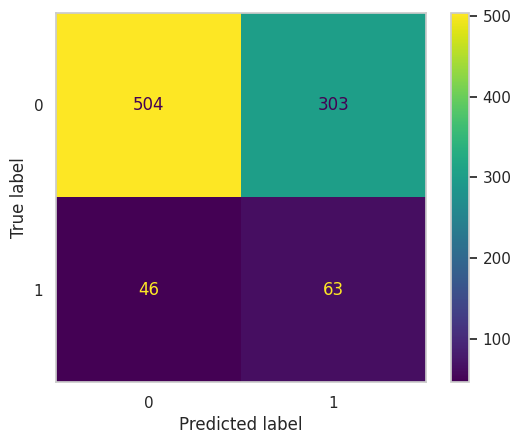


--- ischemic ---


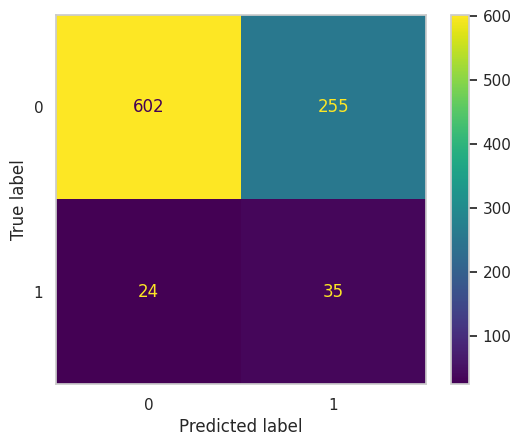


--- generally ---


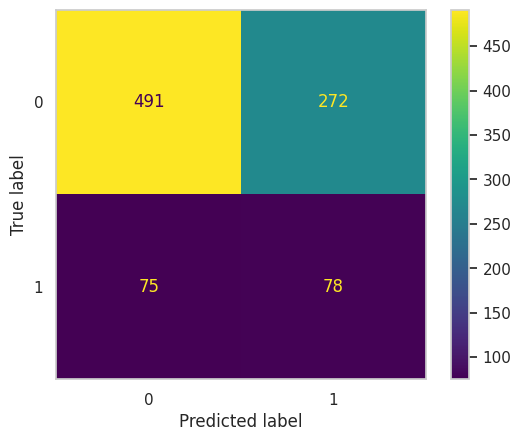

In [7]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# Each of the 9 endpoints is treated as an independent binary target, so the
# classifier is wrapped in MultiOutputClassifier (one LogisticRegression per
# target). class_weight='balanced' compensates for the severe class
# imbalance of these endpoints (1-11% positive rate, see 01_target_exploration).

from sklearn.preprocessing import StandardScaler ## ONlY AS A TEST, NOT IN THE FINAL PIPELINE

pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=32)
    ))
])

print('Cross-validation on the training set')
evaluate_pipeline(X_train, y_train, pipe, average='macro')

# Fit on the full training set after the CV estimate above
pipe.fit(X_train, y_train)

print('Test set performance per target')
y_pred = pipe.predict(X_test)
for i, col in enumerate(y_grouped.columns):
    print(f"\n--- {col} ---")
    disp = ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, i], y_pred[:, i])
    disp.ax_.grid(False)
    plt.show()
    
save_pipeline(PROJECT_DIR, pipe, 'LR_gf_multioutput') # Logistic Regression with grouped features, multioutput

## Multi-output RandomForest Classification Pipeline

Split the data, build a scaling + random forest for multi-output classification, cross-validate it on the training set, fit it, and report per-target classification metrics on the held-out test set. Predictions use a per-target probability threshold tuned to the training-set event rate instead of the default 0.5, since RandomForest's averaged probabilities rarely exceed 0.5 for these rare-event targets (the CV F1 scores above are still computed at the default threshold, so they remain low for the same reason).

Cross-validation on the training set



--- bleeding ---
F1 scores: [0.47152127 0.47113997 0.47113997 0.47148014 0.47148014]
Mean F1:   0.4714 ± 0.0002



--- ischemic ---
F1 scores: [0.48234463 0.48234463 0.48234463 0.48268551 0.48268551]
Mean F1:   0.4825 ± 0.0002



--- generally ---
F1 scores: [0.45663454 0.45663454 0.45623145 0.45657016 0.45657016]
Mean F1:   0.4565 ± 0.0002


Test set performance per target

--- bleeding ---


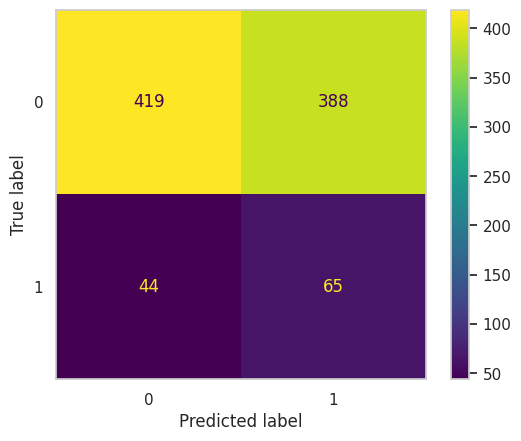


--- ischemic ---


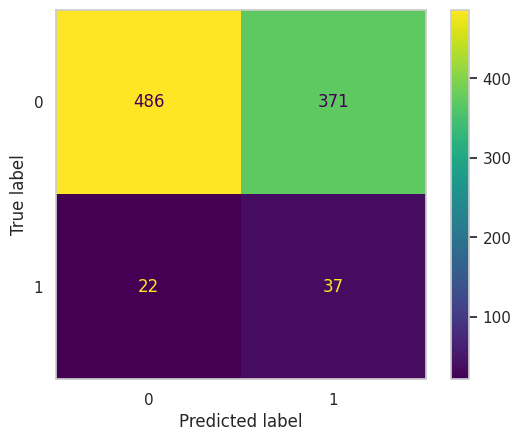


--- generally ---


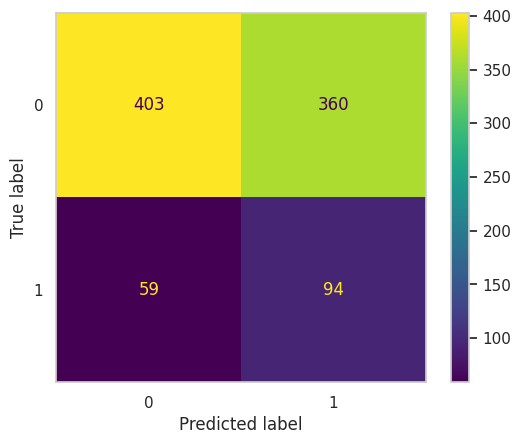

In [8]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# One random forest per target (bleeding / ischemic) via MultiOutputClassifier.
# class_weight='balanced' reweights the impurity/leaf-value computation, but
# unlike LogisticRegression it does not shift the 0.5 decision threshold used
# by .predict(): at a ~7-11% event rate the averaged probability across all
# trees rarely exceeds 0.5, so .predict() would return 0 for every sample.
pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=32)
    ))
])

print('Cross-validation on the training set')
evaluate_pipeline(X_train, y_train, pipe, average='macro')

# Fit on the full training set after the CV estimate above
pipe.fit(X_train, y_train)

print('Test set performance per target')
# Use each target's training-set event rate as its decision threshold
# instead of the default 0.5 (see predict_with_threshold above).
thresholds = y_train.mean().to_numpy()
y_pred = predict_with_threshold(pipe, X_test, thresholds)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    disp = ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, i], y_pred[:, i])
    disp.ax_.grid(False)
    plt.show()
    
save_pipeline(PROJECT_DIR, pipe, 'RF_gf_multioutput') # random forest with grouped features, multioutput

Cross-validation on the training set



--- bleeding ---
F1 scores: [0.48067482 0.49486596 0.48015899 0.49482402 0.48219462]
Mean F1:   0.4865 ± 0.0068



--- ischemic ---
F1 scores: [0.48087819 0.48087819 0.51727457 0.48231966 0.48085106]
Mean F1:   0.4884 ± 0.0144



--- generally ---
F1 scores: [0.49355136 0.4546131  0.50123224 0.4630145  0.4630145 ]
Mean F1:   0.4751 ± 0.0186


Test set performance per target

--- bleeding ---


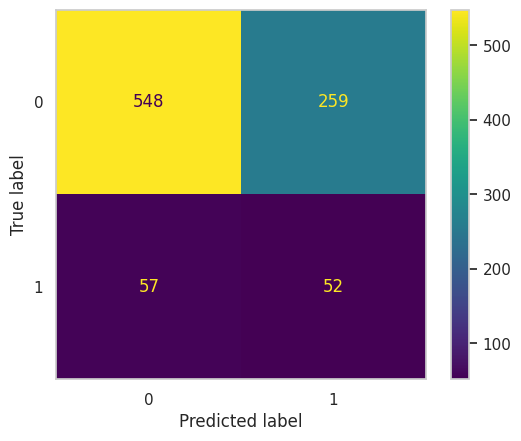


--- ischemic ---


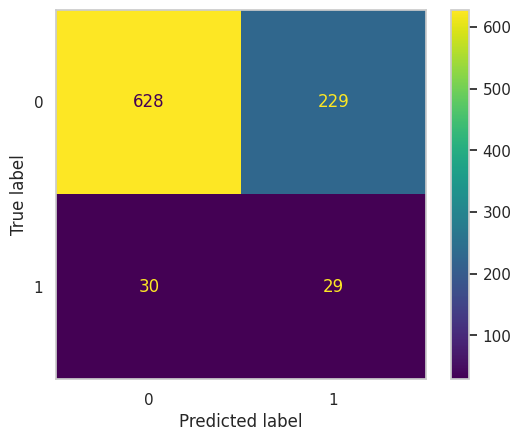


--- generally ---


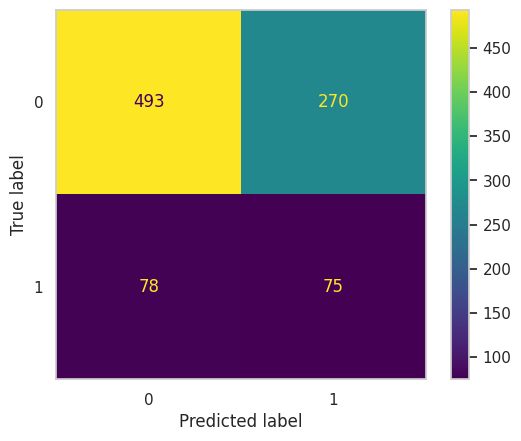

In [9]:
X_train = X_train.select_dtypes(include=[np.number])  # keep numeric features only
X_test = X_test.select_dtypes(include=[np.number])    # keep numeric features only

# One gradient boosting tree per target (bleeding / ischemic) via MultiOutputClassifier.
# class_weight='balanced' reweights the impurity/leaf-value computation, but
# unlike LogisticRegression it does not shift the 0.5 decision threshold used
# by .predict(): at a ~7-11% event rate the averaged probability across all
# trees rarely exceeds 0.5, so .predict() would return 0 for every sample.
pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(random_state=42)
    ))
])

print('Cross-validation on the training set')
evaluate_pipeline(X_train, y_train, pipe, average='macro')

# Fit on the full training set after the CV estimate above
pipe.fit(X_train, y_train)

print('Test set performance per target')
# Use each target's training-set event rate as its decision threshold
# instead of the default 0.5 (see predict_with_threshold above).
thresholds = y_train.mean().to_numpy()
y_pred = predict_with_threshold(pipe, X_test, thresholds)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    disp = ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, i], y_pred[:, i])
    disp.ax_.grid(False)
    plt.show()

save_pipeline(PROJECT_DIR, pipe, 'GB_gf_multioutput') # gradient boosting with grouped features, multioutput

## Bayesian Hyperparameter Tuning

Random and grid search waste budget exploring the whole parameter space uniformly. Optuna's Tree-structured Parzen Estimator (TPE) builds a probabilistic model of the objective surface after each trial and concentrates subsequent trials where the objective is likely to be high.

**Objective**: mean macro precision across all targets on the training set (3-fold CV).
**Trials**: 50 / 30 / 20 for Logistic Regression / Random Forest / Gradient Boosting.
After the search, the best hyperparameters are used to fit the final model and evaluate it on the held-out test set — using the same evaluation protocol as the baseline models above (standard `.predict()` for LR, threshold-tuned probabilities for RF and GB).

In [10]:
import optuna
from sklearn.metrics import make_scorer, precision_score, f1_score

optuna.logging.set_verbosity(optuna.logging.WARNING)


def _multioutput_macro_precision(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return float(np.mean([
        precision_score(y_true[:, i], y_pred[:, i], average='macro', zero_division=0)
        for i in range(y_true.shape[1])
    ]))
    
def _multioutput_f1(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    return float(np.mean([
        f1_score(y_true[:, i], y_pred[:, i], average='macro', zero_division=0)
        for i in range(y_true.shape[1])
    ]))


_mo_scorer = make_scorer(_multioutput_macro_precision)
_f1_scorer = make_scorer(_multioutput_f1)


def mean_cv_f1(pipeline, X, y, cv=3):
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=_f1_scorer, error_score=np.nan)
    return float(np.nanmean(scores))

### Logistic Regression

Search space: regularisation strength `C` (log-uniform in [0.001, 100]) and `solver` (lbfgs / liblinear / saga, all with L2 penalty).

In [11]:
def _lr_objective(trial):
    C = trial.suggest_float('C', 1e-3, 1e2, log=True)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            LogisticRegression(C=C, solver=solver, max_iter=2000,
                               random_state=42, class_weight='balanced'),
            n_jobs=-1,
        )),
    ])
    return mean_cv_f1(pipe, X_train, y_train)


study_lr = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_lr.optimize(_lr_objective, n_trials=50, show_progress_bar=True)

# Baseline (default C=1, lbfgs) for delta comparison
_baseline_lr_precision = mean_cv_f1(Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_lr.best_params)
print(f'Tuned  CV macro-precision: {study_lr.best_value:.4f}')
print(f'Base   CV macro-precision: {_baseline_lr_precision:.4f}  '
      f'(Δ = {study_lr.best_value - _baseline_lr_precision:+.4f})')

  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.48911:   0%|          | 0/50 [00:05<?, ?it/s]

Best trial: 0. Best value: 0.48911:   2%|▏         | 1/50 [00:05<04:34,  5.60s/it]

Best trial: 0. Best value: 0.48911:   2%|▏         | 1/50 [00:15<04:34,  5.60s/it]

Best trial: 0. Best value: 0.48911:   4%|▍         | 2/50 [00:15<06:26,  8.05s/it]

...

Best trial: 30. Best value: 0.491785:  98%|█████████▊| 49/50 [02:04<00:02,  2.28s/it]

Best trial: 30. Best value: 0.491785:  98%|█████████▊| 49/50 [02:04<00:02,  2.28s/it]

Best trial: 30. Best value: 0.491785: 100%|██████████| 50/50 [02:04<00:00,  1.78s/it]

Best trial: 30. Best value: 0.491785: 100%|██████████| 50/50 [02:04<00:00,  2.49s/it]

Best params: {'C': 0.5060467092705161, 'solver': 'lbfgs'}
Tuned  CV macro-precision: 0.4918
Base   CV macro-precision: 0.4909  (Δ = +0.0009)


Test set performance — Tuned Logistic Regression

--- bleeding ---
              precision    recall  f1-score   support

         0.0       0.92      0.62      0.74       807
         1.0       0.17      0.58      0.27       109

    accuracy                           0.62       916
   macro avg       0.54      0.60      0.50       916
weighted avg       0.83      0.62      0.69       916



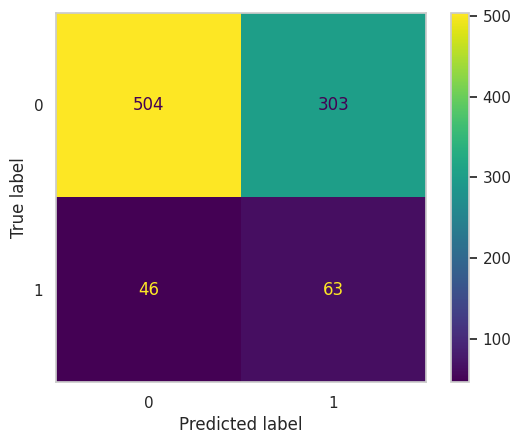


--- ischemic ---
              precision    recall  f1-score   support

         0.0       0.96      0.70      0.81       857
         1.0       0.12      0.59      0.20        59

    accuracy                           0.69       916
   macro avg       0.54      0.65      0.51       916
weighted avg       0.91      0.69      0.77       916



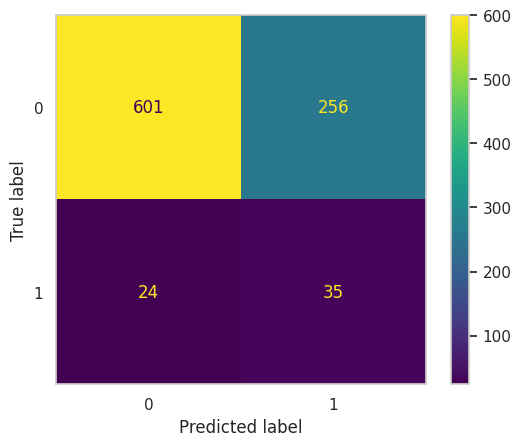


--- generally ---
              precision    recall  f1-score   support

         0.0       0.87      0.64      0.74       763
         1.0       0.22      0.50      0.31       153

    accuracy                           0.62       916
   macro avg       0.54      0.57      0.52       916
weighted avg       0.76      0.62      0.67       916



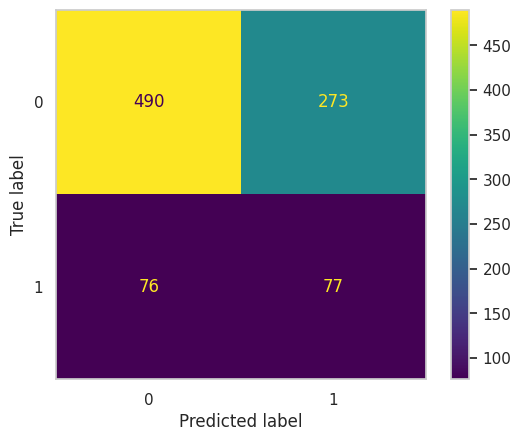

In [12]:
_p = study_lr.best_params
best_lr_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        LogisticRegression(C=_p['C'], solver=_p['solver'],
                           max_iter=2000, random_state=42, class_weight='balanced'),
        n_jobs=-1,
    )),
])
best_lr_pipe.fit(X_train, y_train)

print('Test set performance — Tuned Logistic Regression')
_y_pred = best_lr_pipe.predict(X_test)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], _y_pred[:, i], zero_division=0))
    disp = ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, i], _y_pred[:, i])
    disp.ax_.grid(False)
    plt.show()

### Random Forest

Search space: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`. For the test evaluation the per-target decision threshold is derived from the (1 − event_rate) quantile of the model's predicted training-set probabilities, making it adaptive to the actual probability range produced by the tuned hyperparameters.

In [13]:
def _rf_objective(trial):
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 500, step=50),
                max_depth=trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                random_state=42, n_jobs=3, class_weight='balanced'
            ),
            n_jobs=-1,
        )),
    ])
    return mean_cv_f1(pipe, X_train, y_train)


study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(_rf_objective, n_trials=30, show_progress_bar=True)

_baseline_rf_precision = mean_cv_f1(Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(random_state=42, n_jobs=3, class_weight='balanced'),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_rf.best_params)
print(f'Tuned  CV macro-precision: {study_rf.best_value:.4f}')
print(f'Base   CV macro-precision: {_baseline_rf_precision:.4f}  '
      f'(Δ = {study_rf.best_value - _baseline_rf_precision:+.4f})')

  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.494055:   0%|          | 0/30 [00:03<?, ?it/s]

Best trial: 0. Best value: 0.494055:   3%|▎         | 1/30 [00:03<01:36,  3.33s/it]

Best trial: 0. Best value: 0.494055:   3%|▎         | 1/30 [00:04<01:36,  3.33s/it]

Best trial: 0. Best value: 0.494055:   7%|▋         | 2/30 [00:04<01:03,  2.28s/it]

...

Best trial: 10. Best value: 0.540657:  97%|█████████▋| 29/30 [01:40<00:03,  3.32s/it]

Best trial: 10. Best value: 0.540657:  97%|█████████▋| 29/30 [01:43<00:03,  3.32s/it]

Best trial: 10. Best value: 0.540657: 100%|██████████| 30/30 [01:43<00:00,  3.20s/it]

Best trial: 10. Best value: 0.540657: 100%|██████████| 30/30 [01:43<00:00,  3.46s/it]

Best params: {'n_estimators': 250, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'log2'}
Tuned  CV macro-precision: 0.5407
Base   CV macro-precision: 0.4701  (Δ = +0.0705)


Test set performance — Tuned Random Forest



--- bleeding ---
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90       807
         1.0       0.23      0.19      0.21       109

    accuracy                           0.83       916
   macro avg       0.56      0.55      0.55       916
weighted avg       0.81      0.83      0.82       916



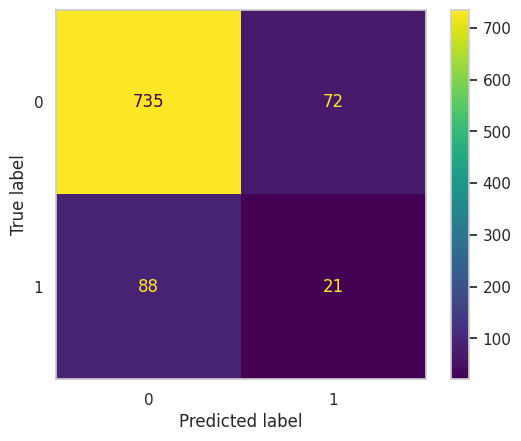


--- ischemic ---
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95       857
         1.0       0.20      0.15      0.17        59

    accuracy                           0.91       916
   macro avg       0.57      0.55      0.56       916
weighted avg       0.89      0.91      0.90       916



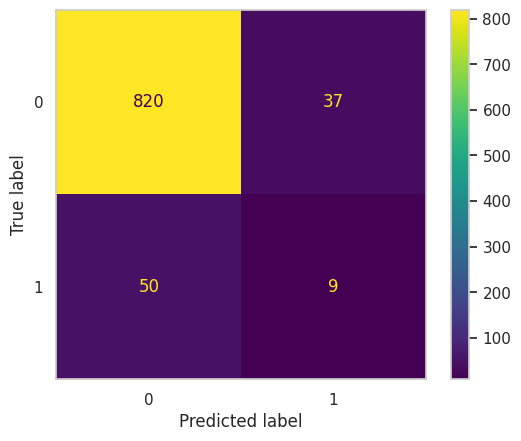


--- generally ---
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87       763
         1.0       0.31      0.27      0.29       153

    accuracy                           0.78       916
   macro avg       0.59      0.58      0.58       916
weighted avg       0.77      0.78      0.77       916



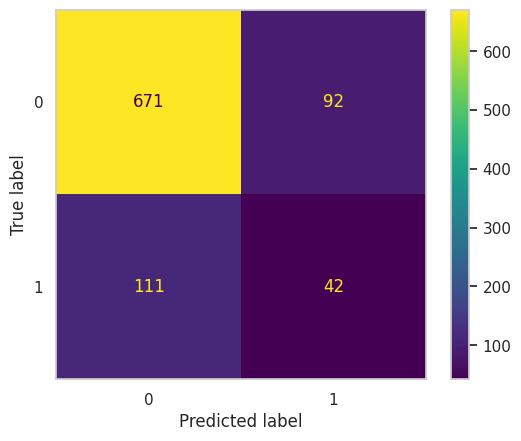

In [14]:
_p = study_rf.best_params
best_rf_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=_p['n_estimators'], max_depth=_p['max_depth'],
            min_samples_split=_p['min_samples_split'],
            min_samples_leaf=_p['min_samples_leaf'],
            max_features=_p['max_features'],
            class_weight='balanced', random_state=42, n_jobs=-1,
        ),
        n_jobs=-1,
    )),
])
best_rf_pipe.fit(X_train, y_train)

# Derive thresholds from the training-set probability distribution rather than
# from the raw event rate.  With class_weight='balanced' + shallow trees the
# RF probabilities are shifted upward and a naive event-rate cutoff (≈7–16 %)
# would flag every sample as positive.  Using the (1−event_rate) quantile of
# the *predicted* training probabilities keeps the fraction of predicted
# positives consistent with the true positive rate, regardless of depth or
# class weighting.
_X_tr = best_rf_pipe[:-1].transform(X_train)
_proba_tr = np.stack(
    [est.predict_proba(_X_tr)[:, 1]
     for est in best_rf_pipe.named_steps['classifier'].estimators_],
    axis=1,
)
_thresholds = np.array([
    np.quantile(_proba_tr[:, i], 1.0 - float(y_train.iloc[:, i].mean()))
    for i in range(_proba_tr.shape[1])
])

print('Test set performance — Tuned Random Forest')
_y_pred = predict_with_threshold(best_rf_pipe, X_test, _thresholds)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], _y_pred[:, i], zero_division=0))
    disp = ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, i], _y_pred[:, i])
    disp.ax_.grid(False)
    plt.show()


### Gradient Boosting

Search space: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `min_samples_split`, `max_features`. Same quantile-based evaluation as RF.

In [15]:
def _gb_objective(trial):
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('classifier', MultiOutputClassifier(
            GradientBoostingClassifier(
                n_estimators=trial.suggest_int('n_estimators', 50, 500, step=50),
                max_depth=trial.suggest_int('max_depth', 2, 6),
                learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample=trial.suggest_float('subsample', 0.6, 1.0),
                min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
                max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                random_state=42,
            ),
            n_jobs=-1,
        )),
    ])
    return mean_cv_f1(pipe, X_train, y_train)


study_gb = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_gb.optimize(_gb_objective, n_trials=20, show_progress_bar=True)

_baseline_gb_precision = mean_cv_f1(Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(random_state=42),
        n_jobs=-1,
    )),
]), X_train, y_train)

print('Best params:', study_gb.best_params)
print(f'Tuned  CV macro-precision: {study_gb.best_value:.4f}')
print(f'Base   CV macro-precision: {_baseline_gb_precision:.4f}  '
      f'(Δ = {study_gb.best_value - _baseline_gb_precision:+.4f})')

  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.483813:   0%|          | 0/20 [00:02<?, ?it/s]

Best trial: 0. Best value: 0.483813:   5%|▌         | 1/20 [00:02<00:45,  2.40s/it]

Best trial: 1. Best value: 0.491362:   5%|▌         | 1/20 [00:05<00:45,  2.40s/it]

Best trial: 1. Best value: 0.491362:  10%|█         | 2/20 [00:05<00:55,  3.08s/it]

...

Best trial: 16. Best value: 0.501158:  95%|█████████▌| 19/20 [00:43<00:02,  2.60s/it]

Best trial: 16. Best value: 0.501158:  95%|█████████▌| 19/20 [00:46<00:02,  2.60s/it]

Best trial: 16. Best value: 0.501158: 100%|██████████| 20/20 [00:46<00:00,  2.79s/it]

Best trial: 16. Best value: 0.501158: 100%|██████████| 20/20 [00:46<00:00,  2.34s/it]

Best params: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.19570462295453636, 'subsample': 0.651685924427302, 'min_samples_split': 12, 'max_features': 'sqrt'}
Tuned  CV macro-precision: 0.5012
Base   CV macro-precision: 0.4835  (Δ = +0.0176)


Test set performance — Tuned Gradient Boosting

--- bleeding ---
              precision    recall  f1-score   support

         0.0       0.89      0.94      0.91       807
         1.0       0.18      0.10      0.13       109

    accuracy                           0.84       916
   macro avg       0.53      0.52      0.52       916
weighted avg       0.80      0.84      0.82       916



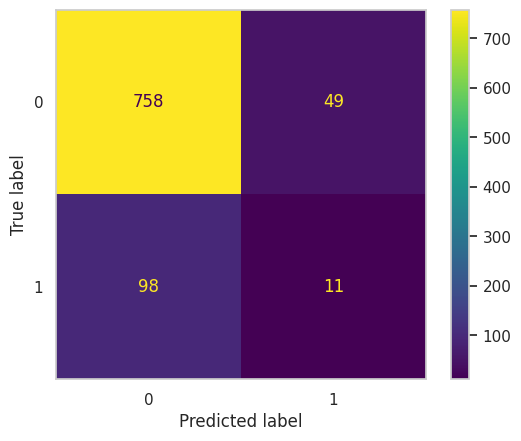


--- ischemic ---
              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96       857
         1.0       0.09      0.03      0.05        59

    accuracy                           0.92       916
   macro avg       0.51      0.51      0.50       916
weighted avg       0.88      0.92      0.90       916



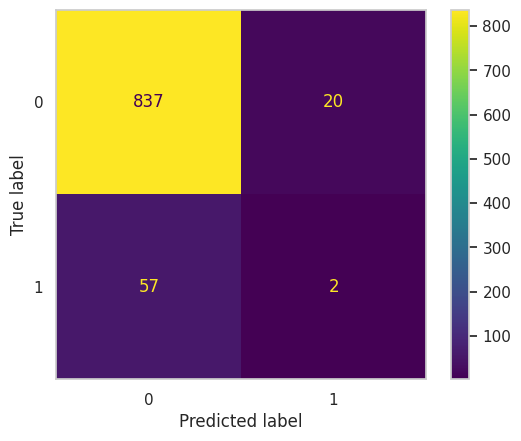


--- generally ---
              precision    recall  f1-score   support

         0.0       0.84      0.87      0.85       763
         1.0       0.18      0.14      0.16       153

    accuracy                           0.75       916
   macro avg       0.51      0.51      0.51       916
weighted avg       0.73      0.75      0.74       916



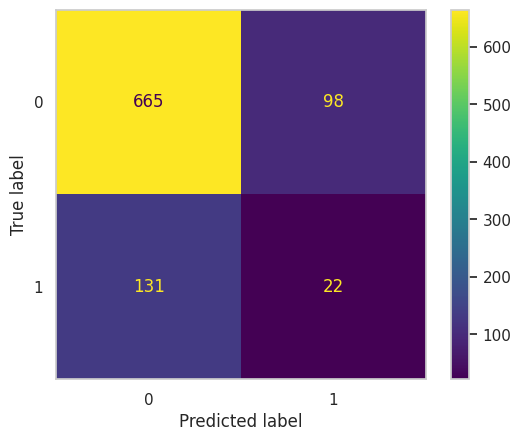

In [16]:
_p = study_gb.best_params
best_gb_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('classifier', MultiOutputClassifier(
        GradientBoostingClassifier(
            n_estimators=_p['n_estimators'], max_depth=_p['max_depth'],
            learning_rate=_p['learning_rate'], subsample=_p['subsample'],
            min_samples_split=_p['min_samples_split'], max_features=_p['max_features'],
            random_state=42,
        ),
        n_jobs=-1,
    )),
])
best_gb_pipe.fit(X_train, y_train)

# Same quantile-based threshold as for the tuned RF above, for consistency.
_X_tr = best_gb_pipe[:-1].transform(X_train)
_proba_tr = np.stack(
    [est.predict_proba(_X_tr)[:, 1]
     for est in best_gb_pipe.named_steps['classifier'].estimators_],
    axis=1,
)
_thresholds = np.array([
    np.quantile(_proba_tr[:, i], 1.0 - float(y_train.iloc[:, i].mean()))
    for i in range(_proba_tr.shape[1])
])

print('Test set performance — Tuned Gradient Boosting')
_y_pred = predict_with_threshold(best_gb_pipe, X_test, _thresholds)
for i, col in enumerate(y_test.columns):
    print(f"\n--- {col} ---")
    print(classification_report(y_test.iloc[:, i], _y_pred[:, i], zero_division=0))
    disp = ConfusionMatrixDisplay.from_predictions(y_test.iloc[:, i], _y_pred[:, i])
    disp.ax_.grid(False)
    plt.show()


### Summary

Comparison of cross-validated mean macro precision (3-fold, training set) before and after Bayesian tuning, and the convergence of the best-so-far objective across trials.

              Model  Baseline CV F1  Tuned CV F1  Δ F1
Logistic Regression            0.49         0.49  0.00
      Random Forest            0.47         0.54  0.07
  Gradient Boosting            0.48         0.50  0.02


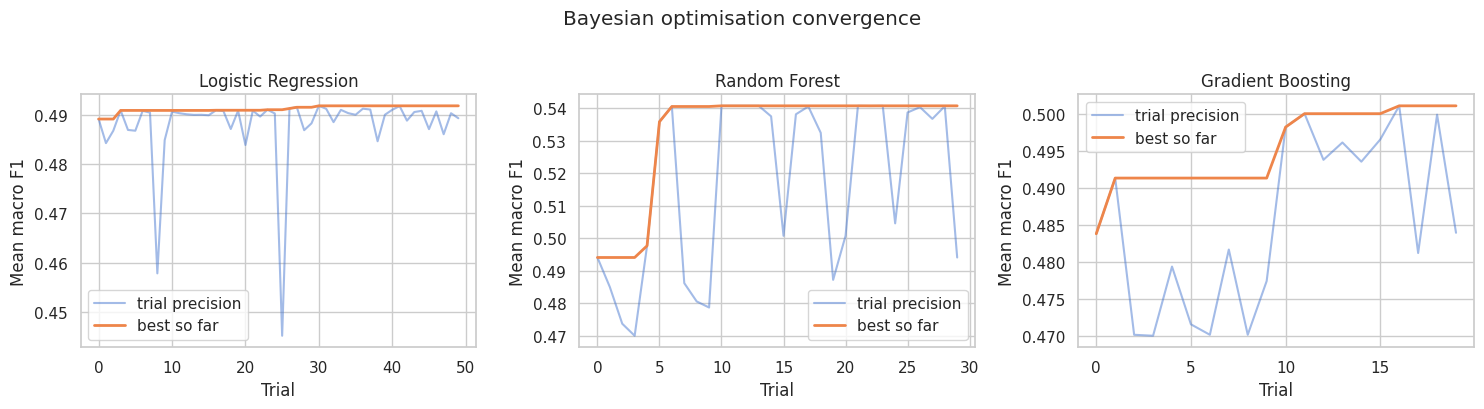

In [17]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Baseline CV F1': [_baseline_lr_precision, _baseline_rf_precision, _baseline_gb_precision],
    'Tuned CV F1':    [study_lr.best_value, study_rf.best_value, study_gb.best_value],
})
comparison['Δ F1'] = comparison['Tuned CV F1'] - comparison['Baseline CV F1']
print(comparison.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (name, study) in zip(
    axes,
    [('Logistic Regression', study_lr),
     ('Random Forest',       study_rf),
     ('Gradient Boosting',   study_gb)],
):
    vals = [t.value for t in study.trials if t.value is not None]
    best_so_far = np.maximum.accumulate(vals)
    ax.plot(vals, alpha=0.5, label='trial precision')
    ax.plot(best_so_far, linewidth=2, label='best so far')
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Mean macro F1')
    ax.legend()
plt.suptitle('Bayesian optimisation convergence', y=1.02)
plt.tight_layout()
plt.show()